DATOS XOR
  Entrada [0 0]  →  Salida esperada: 0
  Entrada [0 1]  →  Salida esperada: 1
  Entrada [1 0]  →  Salida esperada: 1
  Entrada [1 1]  →  Salida esperada: 0

Parametros de la red: 33

ENTRENAMIENTO PSO
  Iter    0  |  MSE = 0.23656772
  Iter  100  |  MSE = 0.00000000
  Iter  200  |  MSE = 0.00000000
  Iter  300  |  MSE = 0.00000000
  Iter  400  |  MSE = 0.00000000
  Iter  500  |  MSE = 0.00000000
  Iter  599  |  MSE = 0.00000000

RESULTADOS
  Mejor MSE alcanzado: 0.00000000

  [0 0]  esperado=0  prob=0.0000  clase=0  [OK]
  [0 1]  esperado=1  prob=1.0000  clase=1  [OK]
  [1 0]  esperado=1  prob=1.0000  clase=1  [OK]
  [1 1]  esperado=0  prob=0.0000  clase=0  [OK]

  Clasificacion 100% correcta: True


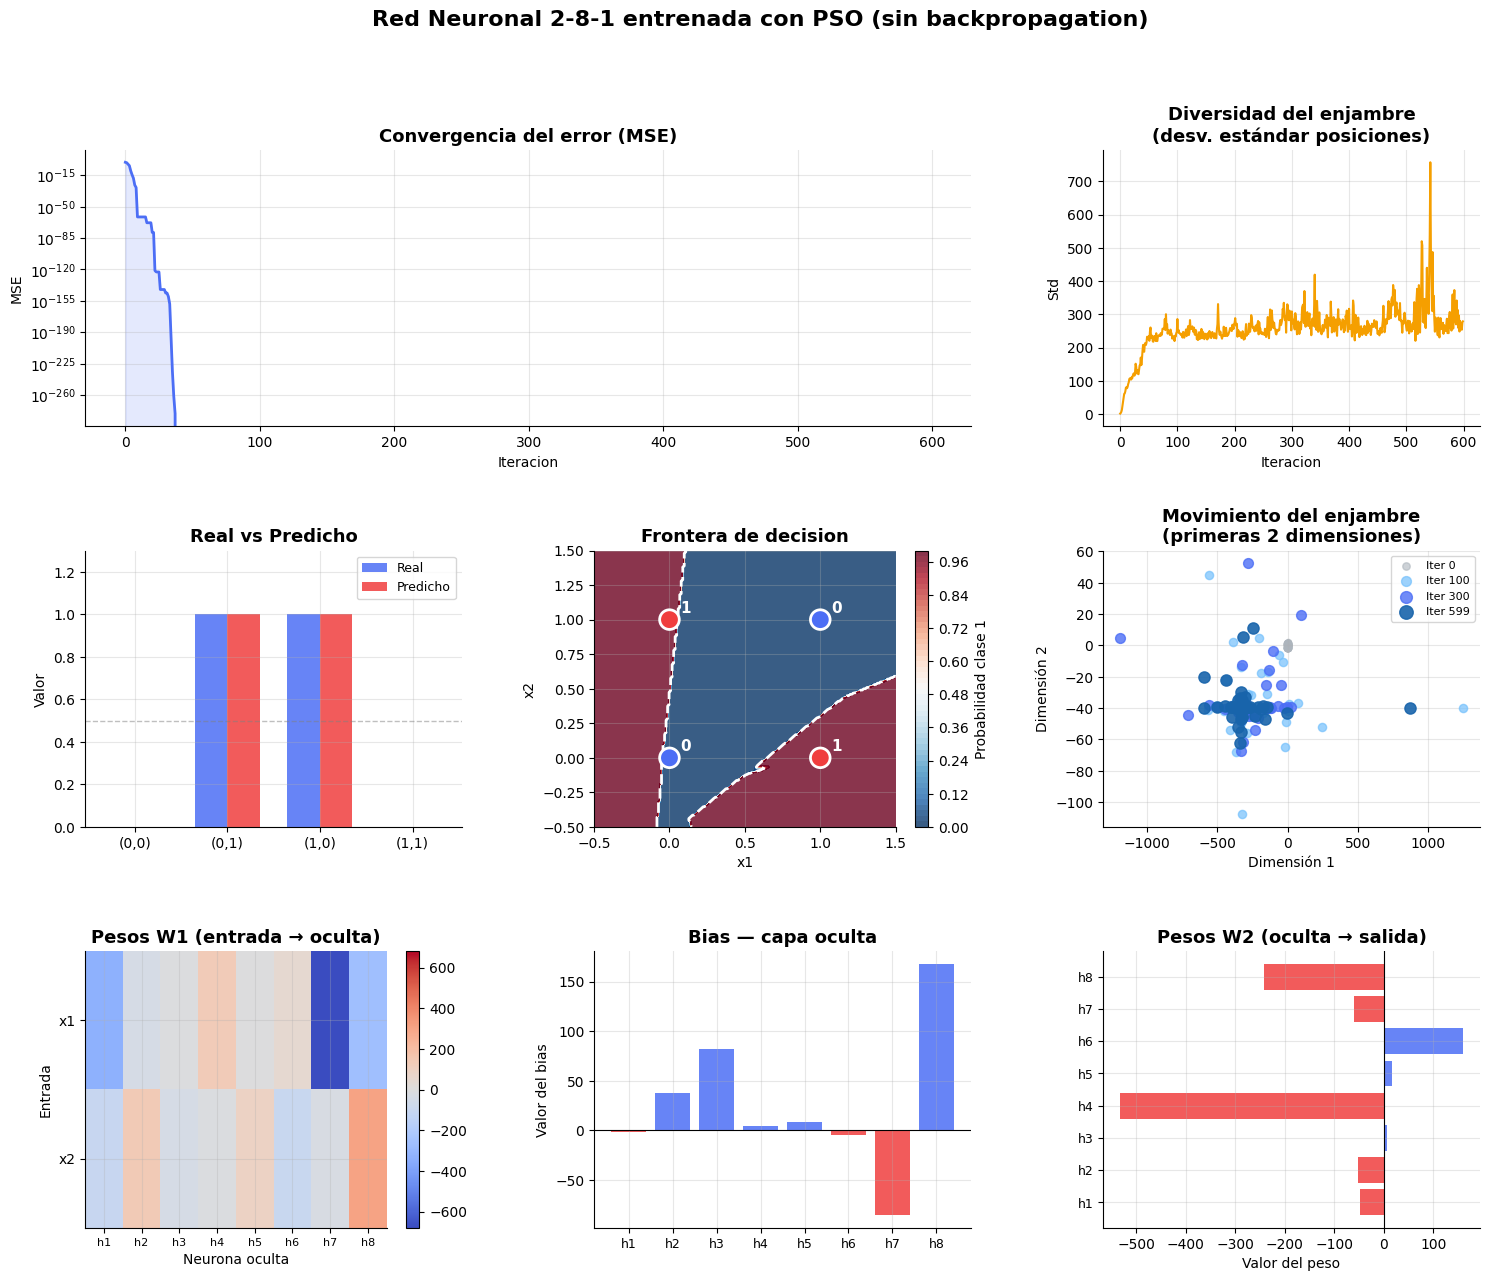


Grafico guardado en red_neuronal_pso.png


In [ ]:
# ==============================================================
# RED NEURONAL ENTRENADA CON OPTIMIZACION POR ENJAMBRE (PSO)
# SIN BACKPROPAGATION
# Problema: XOR — clasificacion no lineal clasica
# Arquitectura: 2 entradas -> 8 neuronas ocultas -> 1 salida
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os # Import the os module

np.random.seed(42)

plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'font.family':        'DejaVu Sans',
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
})
COLORES = ['#4C6EF5', '#F03E3E', '#2F9E44', '#F59F00', '#AE3EC9']


X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
Y = np.array([[0], [1], [1], [0]])

print("=" * 50)
print("DATOS XOR")
print("=" * 50)
for xi, yi in zip(X, Y):
    print(f"  Entrada {xi}  →  Salida esperada: {yi[0]}")


# ====ARQUITECTURA DE LA RED (2-8-1)
#
#  Capa entrada:  2 neuronas  (x1, x2)
#  Capa oculta:   8 neuronas  (activacion sigmoide)
#  Capa salida:   1 neurona   (activacion sigmoide)
#
#  Total de parametros:
#    W1 = 2×8  = 16  pesos
#    b1 = 1×8  =  8  bias
#    W2 = 8×1  =  8  pesos
#    b2 = 1×1  =  1  bias
#    TOTAL      = 33  valores reales a optimizar
# ==============================================================

N_ENTRADA = 2
N_OCULTA  = 8
N_SALIDA  = 1
DIM       = N_ENTRADA * N_OCULTA + N_OCULTA + N_OCULTA * N_SALIDA + N_SALIDA

print(f"\nParametros de la red: {DIM}")


# ==============================================================
#  FUNCIONES DE LA RED NEURONAL
# ==============================================================

def sigmoid(z):
    """Activacion sigmoide: convierte cualquier valor en (0, 1)."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def decodificar(particula):
    """
    Convierte el vector plano de 33 numeros en las matrices
    de pesos y vectores de bias de la red.
    """
    i = 0
    W1 = particula[i:i+16].reshape(N_ENTRADA, N_OCULTA); i += 16
    b1 = particula[i:i+8].reshape(1, N_OCULTA);          i +=  8
    W2 = particula[i:i+8].reshape(N_OCULTA, N_SALIDA);   i +=  8
    b2 = particula[i:   ].reshape(1, N_SALIDA)
    return W1, b1, W2, b2


def forward(particula, X_entrada):
    """
    Propagacion hacia adelante (forward pass):
      - Capa oculta:  h  = sigmoid(X @ W1 + b1)
      - Capa salida:  y  = sigmoid(h @ W2 + b2)
    """
    W1, b1, W2, b2 = decodificar(particula)
    h = sigmoid(X_entrada @ W1 + b1)
    y = sigmoid(h @ W2 + b2)
    return y


def aptitud(particula):
    """
    Funcion objetivo: Error Cuadratico Medio (MSE).
    PSO minimiza este valor — cuanto mas cerca de 0, mejor.
    """
    prediccion = forward(particula, X)
    return float(np.mean((Y - prediccion) ** 2))


# ==============================================================
# CONFIGURACION DEL ENJAMBRE
#
#  w  = inercia:  cuanto "recuerda" su velocidad anterior
#  c1 = factor cognitivo: atraccion hacia su mejor posicion
#  c2 = factor social:    atraccion hacia el mejor global
# ==============================================================

N_PARTICULAS = 60
N_ITER       = 600
W            = 0.72   # inercia
C1           = 1.6    # coeficiente cognitivo
C2           = 1.6    # coeficiente social

# Posiciones y velocidades iniciales aleatorias
posiciones  = np.random.uniform(-2,  2,  (N_PARTICULAS, DIM))
velocidades = np.random.uniform(-0.2, 0.2, (N_PARTICULAS, DIM))

# Mejor posicion personal y global
pbest        = posiciones.copy()
pbest_scores = np.array([aptitud(p) for p in posiciones])

mejor_idx  = int(np.argmin(pbest_scores))
gbest      = pbest[mejor_idx].copy()
gbest_score = pbest_scores[mejor_idx]

# Historiales para graficar
historial_error   = []
historial_diversidad = []   # dispersión del enjambre
historial_pos_2d  = []      # primeras 2 dimensiones (visualizacion)
snapshot_iters    = [0, 100, 300, 599]
snapshots         = {}


# ==============================================================
# ENTRENAMIENTO PSO
# Cada "iteracion" = una generacion del enjambre
# ==============================================================

print("\n" + "=" * 50)
print("ENTRENAMIENTO PSO")
print("=" * 50)

for t in range(N_ITER):

    # Guardar snapshot para visualizar movimiento
    if t in snapshot_iters:
        snapshots[t] = posiciones[:, :2].copy()

    for i in range(N_PARTICULAS):

        r1 = np.random.rand(DIM)
        r2 = np.random.rand(DIM)

        # ── Ecuacion de velocidad PSO ──────────────────────────
        velocidades[i] = (
            W  * velocidades[i]                        # inercia
            + C1 * r1 * (pbest[i] - posiciones[i])    # cognitivo
            + C2 * r2 * (gbest    - posiciones[i])    # social
        )

        # ── Actualizar posicion ────────────────────────────────
        posiciones[i] += velocidades[i]

        # ── Evaluar aptitud y actualizar mejores ───────────────
        score = aptitud(posiciones[i])

        if score < pbest_scores[i]:
            pbest_scores[i] = score
            pbest[i]        = posiciones[i].copy()

            if score < gbest_score:
                gbest_score = score
                gbest       = posiciones[i].copy()

    historial_error.append(gbest_score)
    historial_diversidad.append(float(np.std(posiciones)))

    if t % 100 == 0 or t == N_ITER - 1:
        print(f"  Iter {t:4d}  |  MSE = {gbest_score:.8f}")


# ==============================================================
# RESULTADOS FINALES
# ==============================================================

prediccion  = forward(gbest, X)
clasificado = (prediccion > 0.5).astype(int)
correcto    = (clasificado == Y).all()

print("\n" + "=" * 50)
print("RESULTADOS")
print("=" * 50)
print(f"  Mejor MSE alcanzado: {gbest_score:.8f}\n")
for xi, yi, pi, ci in zip(X, Y, prediccion, clasificado):
    marca = "OK" if ci[0] == yi[0] else "FALLA"
    print(f"  {xi}  esperado={yi[0]}  prob={pi[0]:.4f}  clase={ci[0]}  [{marca}]")
print(f"\n  Clasificacion 100% correcta: {correcto}")


# ==============================================================
# GRAFICOS
# ==============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Red Neuronal 2-8-1 entrenada con PSO (sin backpropagation)",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)


# ── 7a. Convergencia del error ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(historial_error, color=COLORES[0], linewidth=2)
ax1.fill_between(range(N_ITER), historial_error, alpha=0.15, color=COLORES[0])
ax1.set_title("Convergencia del error (MSE)")
ax1.set_xlabel("Iteracion")
ax1.set_ylabel("MSE")
ax1.set_yscale('log')
ax1.annotate(f"MSE final\n{gbest_score:.6f}",
             xy=(N_ITER-1, gbest_score),
             xytext=(N_ITER*0.7, gbest_score*50),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=9)


# ── 7b. Diversidad del enjambre ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(historial_diversidad, color=COLORES[3], linewidth=1.5)
ax2.set_title("Diversidad del enjambre\n(desv. estándar posiciones)")
ax2.set_xlabel("Iteracion")
ax2.set_ylabel("Std")


# ── 7c. Real vs Predicho ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
etiquetas = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
x_pos = np.arange(4)
ancho = 0.35
ax3.bar(x_pos - ancho/2, Y.flatten(),    ancho, label='Real',    color=COLORES[0], alpha=0.85)
ax3.bar(x_pos + ancho/2, prediccion.flatten(), ancho, label='Predicho', color=COLORES[1], alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(etiquetas, fontsize=10)
ax3.set_ylim(0, 1.3)
ax3.set_title("Real vs Predicho")
ax3.set_ylabel("Valor")
ax3.legend(fontsize=9)
ax3.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=1, label='Umbral 0.5')


# ── 7d. Frontera de decision ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
xx = np.linspace(-0.5, 1.5, 200)
yy = np.linspace(-0.5, 1.5, 200)
XX, YY = np.meshgrid(xx, yy)
puntos = np.c_[XX.ravel(), YY.ravel()]
ZZ = forward(gbest, puntos).reshape(XX.shape)

cf = ax4.contourf(XX, YY, ZZ, levels=50, cmap='RdBu_r', alpha=0.8)
plt.colorbar(cf, ax=ax4, label='Probabilidad clase 1')
ax4.contour(XX, YY, ZZ, levels=[0.5], colors='white', linewidths=2, linestyles='--')
colores_puntos = [COLORES[0] if y == 0 else COLORES[1] for y in Y.flatten()]
ax4.scatter(X[:, 0], X[:, 1], c=colores_puntos, s=200,
            edgecolors='white', linewidths=2, zorder=5)
for xi, yi in zip(X, Y):
    ax4.annotate(str(yi[0]), xi, textcoords="offset points",
                 xytext=(8, 5), fontsize=11, fontweight='bold', color='white')
ax4.set_title("Frontera de decision")
ax4.set_xlabel("x1")
ax4.set_ylabel("x2")


# ── 7e. Movimiento del enjambre (snapshots) ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
colores_snap = ['#ADB5BD', '#74C0FC', '#4C6EF5', '#1864AB']
for idx, (t, snap) in enumerate(snapshots.items()):
    ax5.scatter(snap[:, 0], snap[:, 1],
                alpha=0.6 + 0.1*idx, s=20 + idx*15,
                color=colores_snap[idx], label=f"Iter {t}", zorder=idx+1)
ax5.set_title("Movimiento del enjambre\n(primeras 2 dimensiones)")
ax5.set_xlabel("Dimensión 1")
ax5.set_ylabel("Dimensión 2")
ax5.legend(fontsize=8, markerscale=1.2)


# ── 7f. Mapa de calor — pesos W1 ───────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
W1, b1, W2, b2 = decodificar(gbest)
im = ax6.imshow(W1, aspect='auto', cmap='coolwarm',
                vmin=-np.abs(W1).max(), vmax=np.abs(W1).max())
plt.colorbar(im, ax=ax6)
ax6.set_title("Pesos W1 (entrada → oculta)")
ax6.set_xlabel("Neurona oculta")
ax6.set_ylabel("Entrada")
ax6.set_yticks([0, 1])
ax6.set_yticklabels(['x1', 'x2'])
ax6.set_xticks(range(N_OCULTA))
ax6.set_xticklabels([f'h{j+1}' for j in range(N_OCULTA)], fontsize=8)


# ── 7g. Bias de la capa oculta ─────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
bvals = b1.flatten()
colores_bias = [COLORES[0] if v >= 0 else COLORES[1] for v in bvals]
ax7.bar(range(N_OCULTA), bvals, color=colores_bias, alpha=0.85)
ax7.axhline(0, color='black', linewidth=0.8)
ax7.set_xticks(range(N_OCULTA))
ax7.set_xticklabels([f'h{j+1}' for j in range(N_OCULTA)], fontsize=9)
ax7.set_title("Bias — capa oculta")
ax7.set_ylabel("Valor del bias")


# ── 7h. Pesos W2 (oculta → salida) ────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
w2vals = W2.flatten()
colores_w2 = [COLORES[0] if v >= 0 else COLORES[1] for v in w2vals]
ax8.barh(range(N_OCULTA), w2vals, color=colores_w2, alpha=0.85)
ax8.axvline(0, color='black', linewidth=0.8)
ax8.set_yticks(range(N_OCULTA))
ax8.set_yticklabels([f'h{j+1}' for j in range(N_OCULTA)], fontsize=9)
ax8.set_title("Pesos W2 (oculta → salida)")
ax8.set_xlabel("Valor del peso")

# Create the directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/red_neuronal_pso.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\nGrafico guardado en red_neuronal_pso.png")